In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
from qiskit.circuit import QuantumCircuit



STANDARD_CLIFFORD_GATES = {
    'id', 'h', 'x', 'y', 'z', 'cx', 'rz', 's', 'sdg', 'measure'
}

def remove_nonstandard_gates(circuit):
    new_circ = QuantumCircuit(*circuit.qregs, *circuit.cregs, name=circuit.name)
    for instr, qargs, cargs in circuit.data:
        if instr.name in STANDARD_CLIFFORD_GATES:
            new_circ.append(instr, qargs, cargs)
    return new_circ
backend = AerSimulator(method='stabilizer')

# Number of shots per circuit
shots = 10000

# Lengths of different mirror circuits to run
lengths = [2, 4, 10, 20, 50, 100]

# Set up the experiment object
# initial_entangling_angle=np.pi/2 ensures RX gates are Clifford
exp = MirrorQA(
    range(6),  # Use 6 qubits, adjust as needed
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=20,
    initial_entangling_angle=np.pi/2,  # Ensures only Clifford RX gates
)
exp.set_run_options(shots=shots)

raw_circuits = exp.circuits()  # This gives you the list of QuantumCircuit objects

# Clean each circuit
cleaned_circuits = [remove_nonstandard_gates(circ) for circ in raw_circuits]

# Now transpile
clifford_basis = ['id', 'h', 'x', 'y', 'z', 'cx', 'rz', 's', 'sdg', 'measure']
clifford_circuits = transpile(cleaned_circuits, basis_gates=clifford_basis)

for circ in cleaned_circuits:
    print({instr[0].name for instr in circ.data})


# Run the experiment with the stabilizer simulator
rb_data = exp.run(backend=backend, circuits=clifford_circuits)

# Print job IDs (for tracking)
print("Job IDs:", rb_data.job_ids)


ValueError: Providing non-standard gates (save_expval_var) through the ``basis_gates`` argument is not allowed. Use the ``target`` parameter instead. You can build a target instance using ``Target.from_configuration()`` and provide custom gate definitions with the ``custom_name_mapping`` argument.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness

backend = AerSimulator(method='stabilizer')

# Number of shots per circuit
shots = 10000

# Lengths of different mirror circuits to run
lengths = [2, 4, 10, 20, 50, 100]

# Set up the experiment object
# initial_entangling_angle=np.pi/2 ensures RX gates are Clifford
exp = MirrorQA(
    range(6),  # Use 6 qubits, adjust as needed
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=20,
    initial_entangling_angle=np.pi/2,  # Ensures only Clifford RX gates
)
exp.set_run_options(shots=shots)

def remove_roerror_gates(circuit):
    new_circ = QuantumCircuit(*circuit.qregs, *circuit.cregs, name=circuit.name)
    for instr, qargs, cargs in circuit.data:
        if instr.name != 'roerror':
            new_circ.append(instr, qargs, cargs)
    return new_circ


#Transpile circuits to Clifford basis (to ensure only Clifford gates)
clifford_basis = ['id', 'h', 'x', 'y', 'z', 'cx','rz'] 
circuits = exp.circuits()
rb_data = exp.run(backend=backend, circuits=circuits)

#clifford_circuits = transpile(exp.circuits(), basis_gates=clifford_basis)
# Do NOT transpile


# Run the experiment with the stabilizer simulator
rb_data = exp.run(backend=backend, circuits=clifford_circuits)

# Print job IDs (for tracking)
print("Job IDs:", rb_data.job_ids)


ValueError: Providing non-standard gates (break_loop) through the ``basis_gates`` argument is not allowed. Use the ``target`` parameter instead. You can build a target instance using ``Target.from_configuration()`` and provide custom gate definitions with the ``custom_name_mapping`` argument.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator


from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness

# Set up the stabilizer simulator backend
backend = AerSimulator(method="stabilizer")

# Define and configure the experiment
# You must set the number of qubits and gate density, etc.
exp = MirrorQA(
    backend=backend,
    #num_qubits=6,
    two_qubit_gate_density=0.25,  # adjust this if needed
    reps=10,                      # number of repetitions
    circuits_per_point=3,        # circuits per data point
)

# Run the experiment
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)

# Optionally plot results if available
if hasattr(rb_data, 'analysis_results'):
    print("Results:", rb_data.analysis_results)


TypeError: MirrorQA.__init__() got an unexpected keyword argument 'reps'

We'll look at Quantum Awesomeness on either a real 127 qubit device, or a small emulated backend.

In [ ]:
real_device = False

if real_device:
    from qiskit_ibm_provider import IBMProvider
    provider = IBMProvider(instance="ibm-q/open/main")
    backend = provider.get_backend('ibm_sherbrooke')
else:
    p = 1e-2
    backend = NoisyBackend(
    num_qubits=6,
    basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"],
    p1=p/10,
    p2=p,
    )

First we set up the experiment. 

Some notes on parameters:
* `range(backend.num_qubits)`: We use the whole device.
* `two_qubit_gate_density=0.25`: Having around half of all qubits involved in an entangling gate seems like a good fraction, and this makes that happen.
* `initial_entangling_angle=np.pi/2`: Default angle is `np.pi/2`, which creates maximally entangled pairs. We'll use `np.pi/2` so we can more easily see the gates when looking at the circuits.
* `num_samples=20`: Number of different sets of random Clifford circuits.

In [ ]:
# number of shots per circuit
shots = 10000

# lengths of different mirror circuits to run
lengths = [2]+[4,10,20,50,100]

# set up the experiment object
exp = MirrorQA(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=20,
    initial_entangling_angle=np.pi/4,
    )
exp.set_run_options(
    shots=shots
)


Now we run it!

In [ ]:
#run
rb_data = exp.run()
print(rb_data.job_ids)

['98beb078-e533-4241-925b-db13d6f07384']


To see what circuits were run, don't use `exp.circuits()` because that will set up a new bunch of circuits. Instead use `exp._static_trans_circuits`, which stores the transpiled circuits that were run.

There are two differences between MQA circuits and MRB circuits:
* MQA places the new layers of the sequence at the beginning and end, whereas MRB places them in the middle.
* MQA inserts `rx` gates on the control qubit of any qubit involved in a CX in the first layer. Leading to entanglement for all pairs involved in a CX in the first layer.

To see what pairs were used for the CX gates in the first layer of each circuit, use `exp._pairs`.

Below are the first two lengths of circuit for the first sequence of random Cliffords. The `Rx(π/4)` gates here are those inserted to create the entangled pairs.

In [ ]:
print('Pairs:', exp._pairs[0])
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(4, 5), (2, 1)]


global phase: π
        ┌───┐ ░ ┌─────────┐┌───┐                 ░ ┌───┐ ░ ┌─────────┐┌───┐ ░ ┌───┐ ░  ░ ┌─┐               
   q_0: ┤ X ├─░─┤ Rz(π/2) ├┤ X ├─────────────────░─┤ X ├─░─┤ Rz(π/2) ├┤ X ├─░─┤ X ├─░──░─┤M├───────────────
        ├───┤ ░ └──┬───┬──┘└───┘                 ░ ├───┤ ░ └──┬───┬──┘└───┘ ░ ├───┤ ░  ░ └╥┘┌─┐            
   q_1: ┤ X ├─░────┤ X ├─────────────────────────░─┤ Z ├─░────┤ X ├─────────░─┤ Z ├─░──░──╫─┤M├────────────
        ├───┤ ░    └─┬─┘   ┌───┐┌─────────┐┌───┐ ░ ├───┤ ░    └─┬─┘         ░ ├───┤ ░  ░  ║ └╥┘┌─┐         
   q_2: ┤ Z ├─░──────■─────┤ H ├┤ Rz(π/4) ├┤ H ├─░─┤ Z ├─░──────■───────────░─┤ Z ├─░──░──╫──╫─┤M├─────────
        └───┘ ░ ┌─────────┐└───┘└─────────┘└───┘ ░ ├───┤ ░ ┌─────────┐┌───┐ ░ ├───┤ ░  ░  ║  ║ └╥┘┌─┐      
   q_3: ──────░─┤ Rz(π/2) ├──────────────────────░─┤ Y ├─░─┤ Rz(π/2) ├┤ Z ├─░─┤ Z ├─░──░──╫──╫──╫─┤M├──────
        ┌───┐ ░ └─────────┘┌───┐┌─────────┐┌───┐ ░ ├───┤ ░ └─────────┘└───┘ ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐   
   q_4: ┤ Z ├─░──────■─────┤ H ├┤ Rz(π/4) ├┤ H ├─░─┤ Z ├─░──────■───────────░─┤ Z ├─░──░──╫──╫──╫──╫─┤M├───
        ├───┤ ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░ ├───┤ ░    ┌─┴─┐         ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐
   q_5: ┤ Y ├─░────┤ X ├─────────────────────────░─┤ Y ├─░────┤ X ├─────────░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├
        └───┘ ░    └───┘                         ░ └───┘ ░    └───┘         ░ └───┘ ░  ░  ║  ║  ║  ║  ║ └╥┘
meas: 6/══════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩═
                                                                                          0  1  2  3  4  5

In [ ]:
print('Pairs:', exp._pairs[1])
exp._static_trans_circuits[1].draw(fold=-1)

Pairs: [(2, 5), (0, 3)]


global phase: 3π/2
        ┌───┐ ░                 ┌───┐┌─────────┐┌───┐ ░       ░ ┌─────────┐┌───┐ ░ ┌───┐ ░ ┌─────────┐┌───┐ ░ ┌───┐ ░                       ░ ┌───┐ ░  ░ ┌─┐               
   q_0: ┤ X ├─░──────────────■──┤ H ├┤ Rz(π/4) ├┤ H ├─░───────░─┤ Rz(π/2) ├┤ X ├─░─┤ Y ├─░─┤ Rz(π/2) ├┤ X ├─░─┤ X ├─░──────────────■────────░─┤ X ├─░──░─┤M├───────────────
        ├───┤ ░ ┌─────────┐  │  └───┘└─────────┘└───┘ ░ ┌───┐ ░ └──┬───┬──┘└───┘ ░ ├───┤ ░ └──┬───┬──┘└───┘ ░ ├───┤ ░ ┌─────────┐  │  ┌───┐ ░ ├───┤ ░  ░ └╥┘┌─┐            
   q_1: ┤ X ├─░─┤ Rz(π/2) ├──┼────────────────────────░─┤ Z ├─░────┤ X ├─────────░─┤ Y ├─░────┤ X ├─────────░─┤ Z ├─░─┤ Rz(π/2) ├──┼──┤ Z ├─░─┤ Z ├─░──░──╫─┤M├────────────
        ├───┤ ░ └─────────┘  │  ┌───┐┌─────────┐┌───┐ ░ ├───┤ ░    └─┬─┘         ░ ├───┤ ░    └─┬─┘         ░ ├───┤ ░ └─────────┘  │  └───┘ ░ ├───┤ ░  ░  ║ └╥┘┌─┐         
   q_2: ┤ Z ├─░──────■───────┼──┤ H ├┤ Rz(π/4) ├┤ H ├─░─┤ Z ├─░──────■───────────░─┤ Y ├─░──────■───────────░─┤ Z ├─░──────■───────┼────────░─┤ Z ├─░──░──╫──╫─┤M├─────────
        └───┘ ░      │     ┌─┴─┐└───┘└─────────┘└───┘ ░ ├───┤ ░ ┌─────────┐      ░ ├───┤ ░ ┌─────────┐┌───┐ ░ ├───┤ ░      │     ┌─┴─┐      ░ ├───┤ ░  ░  ║  ║ └╥┘┌─┐      
   q_3: ──────░──────┼─────┤ X ├──────────────────────░─┤ Y ├─░─┤ Rz(π/2) ├──────░─┤ Y ├─░─┤ Rz(π/2) ├┤ Z ├─░─┤ Y ├─░──────┼─────┤ X ├──────░─┤ Z ├─░──░──╫──╫──╫─┤M├──────
        ┌───┐ ░      │     ├───┤┌───┐                 ░ ├───┤ ░ └─────────┘      ░ ├───┤ ░ └─────────┘└───┘ ░ ├───┤ ░      │     ├───┤┌───┐ ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐   
   q_4: ┤ Z ├─░──────┼─────┤ H ├┤ X ├─────────────────░─┤ Z ├─░──────■───────────░─┤ Z ├─░──────■───────────░─┤ Z ├─░──────┼─────┤ H ├┤ Z ├─░─┤ Z ├─░──░──╫──╫──╫──╫─┤M├───
        ├───┤ ░    ┌─┴─┐   └───┘└───┘                 ░ ├───┤ ░    ┌─┴─┐         ░ ├───┤ ░    ┌─┴─┐         ░ ├───┤ ░    ┌─┴─┐   └───┘└───┘ ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐
   q_5: ┤ Y ├─░────┤ X ├──────────────────────────────░─┤ Y ├─░────┤ X ├─────────░─┤ X ├─░────┤ X ├─────────░─┤ Y ├─░────┤ X ├──────────────░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├
        └───┘ ░    └───┘                              ░ └───┘ ░    └───┘         ░ └───┘ ░    └───┘         ░ └───┘ ░    └───┘              ░ └───┘ ░  ░  ║  ║  ║  ║  ║ └╥┘
meas: 6/══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩═
                                                                                                                                                          0  1  2  3  4  5

Now we can analyze the data according to our desired analysis method.

In [ ]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
#exp.analysis.set_options(analyzed_quantity='Mutual Information')
analysis = exp.analysis.run(rb_data)

Then plot the results.

Note: if you get the `'Figure index 0 out of range.'` error, it might be because the analysis is still running in the background. So just try again.

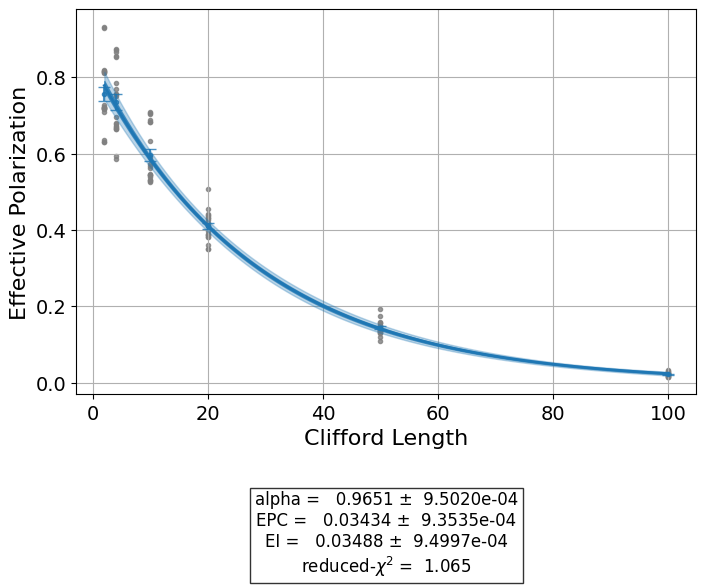

In [ ]:
analysis.figure(0)

When we calculate the mutual informations, it is done by the `QuantumAwesomeness` object. We can also use this directly.

In [ ]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

It can be used to calculate the MIs for each pair in the coupling map for each circuit that was run.

In [ ]:
mi = qa.mutual_info(rb_data.data())

It can also be used to calculate the mean MIs, where separate means are taken for the entangled pairs and the non-entangled pairs.

In [ ]:
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(2)]
yerrs = [[],[]]

for p, pairtype in enumerate(['paired', 'single']):
    for j,m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j%6].append(m)
    for j in range(6):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='singles')
plt.yscale('log')
plt.legend()

Pickled results from a run on `'ibm_sherbrooke'`can be found in the following files.

* `exp`: `'pickled_sherbrooke/exp_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data`: `'pickled_sherbrooke/data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data.data()`: `'pickled_sherbrooke/data_data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `mi`: `'pickled_sherbrooke/mi_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`

